In [32]:
import pandas as pd

# 1. Load your downloaded CSV file
# IMPORTANT: Change 'your_downloaded_file.csv' to the actual name of your file!
file_name = "data/gdelt/bq-results-20260302-194305-1772480601839.csv"
print(f"Loading data from {file_name}...\n")
df = pd.read_csv(file_name)
df.head()


# CLEANING THE DATA: remove duplicate rows
rows_before = len(df)
print(f"Number of rows before removing duplicates: {rows_before}")

df.drop_duplicates(inplace=True)

rows_after = len(df)
print(f"Number of rows after removing duplicates: {rows_after}")


Loading data from data/gdelt/bq-results-20260302-194305-1772480601839.csv...

Number of rows before removing duplicates: 6977
Number of rows after removing duplicates: 5302


In [4]:
df.groupby(['Event_Date', 'Initiator_Country'])['Event_Date'].value_counts()

Event_Date  Initiator_Country
20240101    CHN                  4
20240102    CHN                  7
            RUS                  3
20240103    CHN                  5
20240104    CHN                  2
                                ..
20241229    IRN                  2
20241230    IRN                  2
            RUS                  4
20241231    CHN                  2
            RUS                  4
Name: count, Length: 827, dtype: int64

In [5]:
# Save counts and marks for each country, order by day
df['Date'] = pd.to_datetime(df['Event_Date'].astype(str), format='%Y%m%d', errors='coerce')
daily_counts = df.groupby(['Date', 'Initiator_Country'])['Date'].value_counts().reset_index(name='News')
daily_counts = daily_counts.sort_values('Date')

daily_marks = df.groupby(['Date', 'Initiator_Country'])['Total_Mentions'].sum().reset_index()
daily_marks = daily_marks.sort_values('Date')

# Concat
daily_data = pd.merge(daily_counts, daily_marks, on=['Date', 'Initiator_Country'], how='left')
daily_data.head()

,Date,Initiator_Country,News,Total_Mentions
0,2024-01-01,CHN,4,15
1,2024-01-02,CHN,7,33
2,2024-01-02,RUS,3,13
3,2024-01-03,CHN,5,28
4,2024-01-04,CHN,2,7


In [6]:
daily_data.to_csv('daily_news_data.csv', index=False)

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

daily_df = pd.read_csv('daily_news_data.csv')

# Ensure the Date column is recognized as actual datetime objects
daily_df['Date'] = pd.to_datetime(daily_df['Date'])

# Set up our consistent colors
colors = {'RUS': '#d62728', 'CHN': '#1f77b4', 'IRN': '#2ca02c'}

# =========================================================
# PLOT 1: ALL COUNTRIES ON THE SAME AXIS
# =========================================================
plt.figure(figsize=(15, 6))
sns.lineplot(
    data=daily_df, 
    x='Date', 
    y='News', 
    hue='Initiator_Country',
    palette=colors,
    linewidth=2.5,  # Make lines thicker
    marker='o',     # Add a dot for each week
    markersize=6
)

plt.title('Daily Election Interference News (Combined Axis)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date (2024)', fontsize=14)
plt.ylabel('Total News News (Daily)', fontsize=14)

# Force ticks to appear on months, formatted as abbreviated month names (Jan, Feb)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Actor', loc='upper right')

plt.tight_layout()
output_1 = 'model_plots/Line_Chart_Combined_2024.png'
plt.savefig(output_1, dpi=300)
print(f"Combined line chart saved as: {output_1}")
plt.close() # Close to start the next plot fresh


# =========================================================
# PLOT 2: SEPARATED "LANES" (SUBPLOTS)
# =========================================================
# Create 3 rows and 1 column of charts, sharing the same X-axis
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

country_names = {'RUS': 'Russia', 'CHN': 'China', 'IRN': 'Iran'}

# Loop through our three countries and plot them on their own axis
for i, country in enumerate(['RUS', 'CHN', 'IRN']):
    # Filter the data for just this country
    country_data = daily_df[daily_df['Initiator_Country'] == country]
    
    sns.lineplot(
        data=country_data,
        x='Date',
        y='News',
        color=colors[country],
        ax=axes[i],
        linewidth=2.5,
        marker='o',
        markersize=6
    )
    
    # Format each individual subplot
    axes[i].set_title(f'{country_names[country]} Activity', fontsize=14, fontweight='bold', color=colors[country])
    axes[i].set_ylabel('Daily News', fontsize=12)
    axes[i].set_ylim(0, daily_df['News'].max() * 1.05)  # Set a consistent Y-axis limit for better comparison
    axes[i].grid(True, linestyle='--', alpha=0.5)
    
    # --- NEW: Apply month formatting to EVERY axis ---
    axes[i].xaxis.set_major_locator(mdates.MonthLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    
    # --- NEW: Force the month labels to appear despite sharex=True ---
    axes[i].tick_params(axis='x', labelbottom=True)
    
    # Remove the generic "Date" x-axis label for the top two plots, but keep the months
    if i < 2:
        axes[i].set_xlabel('')
    else:
        axes[i].set_xlabel('Timeline (2024)', fontsize=14)

#plt.suptitle('Daily Election Interference News (Separated by Actor)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

output_2 = 'model_plots/Line_Chart_Separated_2024.png'
plt.savefig(output_2, dpi=300)
print(f"Separated line chart saved as: {output_2}")
plt.close()

Combined line chart saved as: model_plots/Line_Chart_Combined_2024.png
Separated line chart saved as: model_plots/Line_Chart_Separated_2024.png


In [19]:
# Select RUS, fill missing dates with RUS and 0 mentions. Include all dates.
rus_data = daily_data[daily_data['Initiator_Country'] == 'RUS']
rus_data = rus_data.set_index('Date').resample('D').asfreq().fillna({'Initiator_Country': 'RUS', 'News': 0, 'Total_Mentions': 0}).reset_index()
rus_data.head()
rus_data.to_csv("rus_daily_data.csv", index=False)

In [20]:
rus_data

,Date,Initiator_Country,News,Total_Mentions
0,2024-01-02,RUS,3.0,13.0
1,2024-01-03,RUS,0.0,0.0
2,2024-01-04,RUS,0.0,0.0
3,2024-01-05,RUS,0.0,0.0
4,2024-01-06,RUS,2.0,8.0
...,...,...,...,...
360,2024-12-27,RUS,2.0,6.0
361,2024-12-28,RUS,1.0,2.0
362,2024-12-29,RUS,0.0,0.0
363,2024-12-30,RUS,4.0,9.0


In [21]:
# 2. Who is generating the most noise? (Impact by Country)
# This groups the data by Russia (RUS), Iran (IRN), and China (CHN) 
# and adds up their total global mentions.
country_impact = df.groupby('Initiator_Country')[['Total_Mentions', 'Unique_Outlets']].sum()
country_impact = country_impact.sort_values(by='Total_Mentions', ascending=False)

print("--- IMPACT BY ACTOR (TOTAL MENTIONS) ---")
print(country_impact)
print("\n" + "="*40 + "\n")

--- IMPACT BY ACTOR (TOTAL MENTIONS) ---
                   Total_Mentions  Unique_Outlets
Initiator_Country                                
RUS                          8080            2497
CHN                          7698            2057
IRN                          3628            1046




In [22]:
# 3. Clean, Filter, and Count the GKG Themes
top_themes = (
    df['Themes']
    .dropna()
    .str.replace(';', ',') 
    .str.split(',')
    .explode()
    .str.strip()
)
# Remove empty strings
top_themes = top_themes[top_themes != '']

# --- THE NEW FILTERING STEP ---
# This looks for any theme containing these taxonomy prefixes.
# The "~" symbol tells pandas to KEEP everything that DOES NOT match.
noise_patterns = 'TAX_WORLDLANGUAGES_|TAX_ETHNICITY_|USPEC_POLITICS_GENERAL1'
top_themes = top_themes[~top_themes.str.contains(noise_patterns, na=False)]

# Create a clean dataframe of the top 50 themes
themes_df = top_themes.value_counts().head(50).reset_index()
themes_df.columns = ['Theme', 'Count']

print("--- TOP 20 MOST FREQUENT THEMES (CLEANED) ---")
print(themes_df.head(20))
print("\n" + "="*40 + "\n")

--- TOP 20 MOST FREQUENT THEMES (CLEANED) ---
                                                Theme  Count
0                                TAX_FNCACT_PRESIDENT  19350
1                                              LEADER  19208
2                                            ELECTION  15199
3                          EPU_CATS_NATIONAL_SECURITY  14374
4                                  GENERAL_GOVERNMENT  12505
5                                CRISISLEX_C07_SAFETY  12309
6                                       ARMEDCONFLICT  12078
7                               EPU_POLICY_GOVERNMENT  11822
8   WB_133_INFORMATION_AND_COMMUNICATION_TECHNOLOGIES  10030
9                           WB_678_DIGITAL_GOVERNMENT   9797
10                         WB_694_BROADCAST_AND_MEDIA   8935
11            WB_2432_FRAGILITY_CONFLICT_AND_VIOLENCE   8829
12                               EPU_POLICY_POLITICAL   8475
13                               TAX_FNCACT_OFFICIALS   8283
14                             CRISISLE

In [23]:
# 4. Clean and Count the Organizations (Beyond Social Media)
# Let's see which companies, agencies, or groups were mentioned the most
top_orgs = (
    df['All_Organizations_Found']
    .dropna()
    .str.replace(';', ',')
    .str.split(',')
    .explode()
    .str.strip()
)
top_orgs = top_orgs[top_orgs != '']

print("--- TOP 20 MOST FREQUENT ORGANIZATIONS ---")
print(top_orgs.value_counts().head(20))

--- TOP 20 MOST FREQUENT ORGANIZATIONS ---
All_Organizations_Found
United States                     18988
White House                        3011
Cnn                                1820
Microsoft                          1436
Reuters                            1263
Justice Department                 1025
Chinese Communist Party             957
Twitter                             786
New York Times                      703
Facebook                            695
Xinhua                              587
Google                              585
United Nations                      583
National Intelligence               566
European Union                      547
Youtube                             452
Associated Press                    442
Democratic Party                    412
Infrastructure Security Agency      359
Security Council                    333
Name: count, dtype: int64



Plot successfully generated and saved as: Interference_Timeline_2024.png


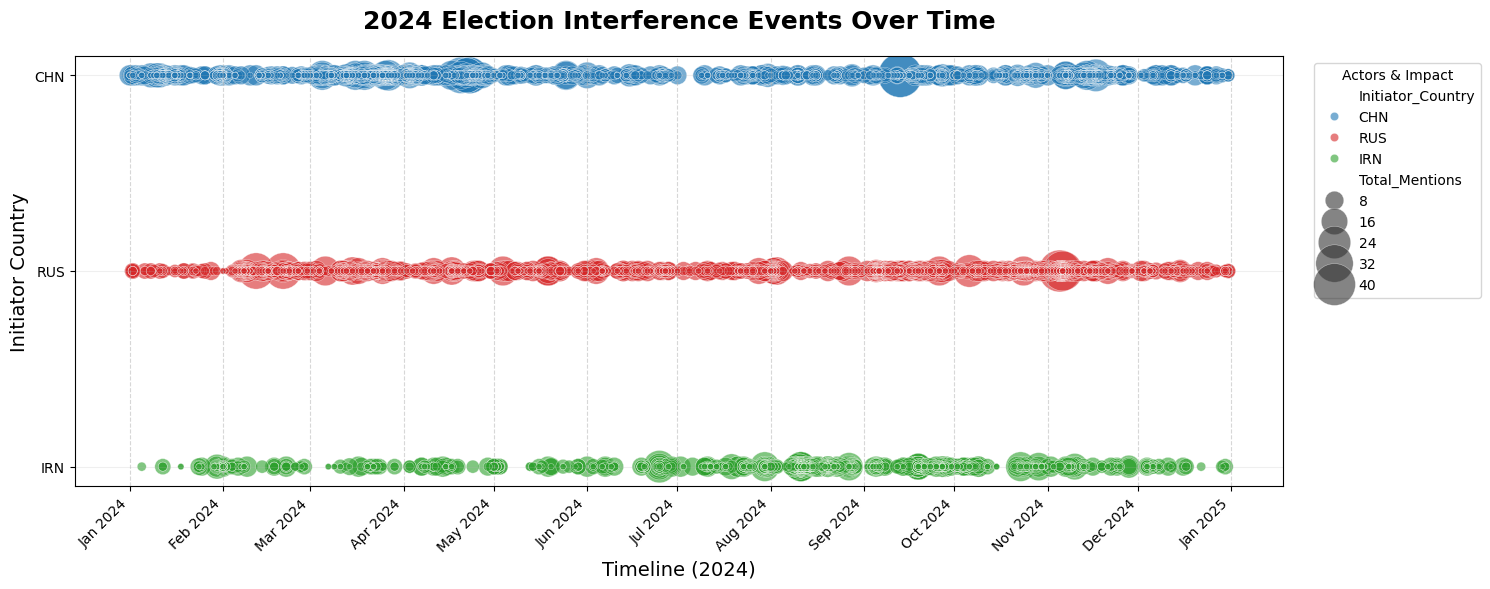

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 1. Load the data (if you haven't already in the main script)
file_name = "bq-results-20260302-194305-1772480601839.csv" # Ensure this matches your file
df = pd.read_csv(file_name)

# 2. Convert the GDELT integer date (YYYYMMDD) into a proper Date object for plotting
df['Date'] = pd.to_datetime(df['Event_Date'].astype(str), format='%Y%m%d', errors='coerce')

# 3. Set up the figure size (wide and horizontal)
plt.figure(figsize=(15, 6))

# 4. Create the scatter plot
# 'x' is time, 'y' is the actor, and 'size' is the impact score
sns.scatterplot(
    data=df, 
    x='Date', 
    y='Initiator_Country', 
    size='Total_Mentions',   # Bubble size depends on the news impact
    sizes=(20, 1000),        # Minimum and Maximum bubble size
    alpha=0.6,               # Make bubbles slightly transparent so overlaps are visible
    hue='Initiator_Country', # Color-code by country
    palette={'RUS': '#d62728', 'IRN': '#2ca02c', 'CHN': '#1f77b4'} # Red, Green, Blue
)

# 5. Format the aesthetics
plt.title('2024 Election Interference Events Over Time', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Timeline (2024)', fontsize=14)
plt.ylabel('Initiator Country', fontsize=14)

# Format the X-axis to show clean month names (e.g., "Jan 2024", "Feb 2024")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, ha='right')

# Add subtle grid lines for readability
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.grid(True, axis='y', linestyle='-', alpha=0.2)

# Move the legend outside the plot so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Actors & Impact')

# 6. Save the plot as a high-resolution image
plt.tight_layout()
output_image = 'Interference_Timeline_2024.png'
plt.savefig(output_image, dpi=300)

print(f"\nPlot successfully generated and saved as: {output_image}")

In [43]:
daily_df = df.groupby([pd.Grouper(key='Date', freq='D'), 'Initiator_Country'])['Date'].value_counts().reset_index()
daily_df

,Date,Initiator_Country,count
0,2024-01-01,CHN,6
1,2024-01-02,CHN,8
2,2024-01-02,RUS,7
3,2024-01-03,CHN,6
4,2024-01-04,CHN,3
...,...,...,...
822,2024-12-29,IRN,2
823,2024-12-30,IRN,3
824,2024-12-30,RUS,7
825,2024-12-31,CHN,6


In [46]:
daily_df = df.groupby([pd.Grouper(key='Date', freq='D'), 'Initiator_Country'])['Date'].value_counts().reset_index()
daily_df.rename(columns={'count': 'News'}, inplace=True)
daily_df

,Date,Initiator_Country,News
0,2024-01-01,CHN,6
1,2024-01-02,CHN,8
2,2024-01-02,RUS,7
3,2024-01-03,CHN,6
4,2024-01-04,CHN,3
...,...,...,...
822,2024-12-29,IRN,2
823,2024-12-30,IRN,3
824,2024-12-30,RUS,7
825,2024-12-31,CHN,6


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 1. Load data and setup dates (if not already done)
file_name = "bq-results-20260302-194305-1772480601839.csv" # Ensure this matches your file
df = pd.read_csv(file_name)
df['Date'] = pd.to_datetime(df['Event_Date'].astype(str), format='%Y%m%d', errors='coerce')

# 2. Smooth the data: Aggregate total mentions by WEEK ('W') and Country
daily_df = df.groupby([pd.Grouper(key='Date', freq='D'), 'Initiator_Country'])['Date'].value_counts().reset_index()
daily_df.rename(columns={'count': 'News'}, inplace=True)

# Set up our consistent colors
colors = {'RUS': '#d62728', 'IRN': '#2ca02c', 'CHN': '#1f77b4'}

# =========================================================
# PLOT 1: ALL COUNTRIES ON THE SAME AXIS
# =========================================================
plt.figure(figsize=(15, 6))
sns.lineplot(
    data=daily_df, 
    x='Date', 
    y='News', 
    hue='Initiator_Country',
    palette=colors,
    linewidth=2.5,  # Make lines thicker
    marker='o',     # Add a dot for each week
    markersize=6
)

plt.title('Daily Election Interference News (Combined Axis)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date (2024)', fontsize=14)
plt.ylabel('Total News News (Daily)', fontsize=14)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Actor', loc='upper right')

plt.tight_layout()
output_1 = 'Line_Chart_Combined_2024.png'
plt.savefig(output_1, dpi=300)
print(f"Combined line chart saved as: {output_1}")
plt.close() # Close to start the next plot fresh


# =========================================================
# PLOT 2: SEPARATED "LANES" (SUBPLOTS)
# =========================================================
# Create 3 rows and 1 column of charts, sharing the same X-axis
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

country_names = {'RUS': 'Russia', 'IRN': 'Iran', 'CHN': 'China'}

# Loop through our three countries and plot them on their own axis
for i, country in enumerate(['RUS', 'IRN', 'CHN']):
    # Filter the data for just this country
    country_data = daily_df[daily_df['Initiator_Country'] == country]
    
    sns.lineplot(
        data=country_data,
        x='Date',
        y='News',
        color=colors[country],
        ax=axes[i],
        linewidth=2.5,
        marker='o',
        markersize=6
    )
    
    # Format each individual subplot
    axes[i].set_title(f'{country_names[country]} Activity', fontsize=14, fontweight='bold', color=colors[country])
    axes[i].set_ylabel('Daily News', fontsize=12)
    axes[i].set_ylim(0, daily_df['News'].max() * 1.05)  # Set a consistent Y-axis limit for better comparison
    axes[i].grid(True, linestyle='--', alpha=0.5)
    
    # Remove the redundant x-axis label for the top two plots
    if i < 2:
        axes[i].set_xlabel('')

# Format the bottom X-axis
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].set_xlabel('Timeline (2024)', fontsize=14)

plt.suptitle('Daily Election Interference News (Separated by Actor)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

output_2 = 'Line_Chart_Separated_2024.png'
plt.savefig(output_2, dpi=300)
print(f"Separated line chart saved as: {output_2}")
plt.close()

Combined line chart saved as: Line_Chart_Combined_2024.png
Separated line chart saved as: Line_Chart_Separated_2024.png


#### Webscrapping

In [33]:
df

,Event_Date,Initiator,Initiator_Country,Target,Total_Mentions,Unique_Outlets,Total_Articles,Article_Tone,Social_Media_Mentioned,All_Organizations_Found,Themes,News_URL
0,20240913,CHINA,CHN,UNITED STATES,44,1,44,-4.736842,NaN,"Sandy Hook Elementary School,4051;Justice Depa...","TAX_WORLDMAMMALS_HUMANS,1053;EPU_POLICY_WHITE_...",https://www.yahoo.com/news/forget-cats-eat-hum...
2,20241105,RUSSIA,RUS,PENNSYLVANIA,40,4,40,-5.792164,NaN,"Embassy Russian,1231;Microsoft,2668;Agency Sec...","TAX_FNCACT_ANALYSTS,2643;TAX_DISEASE_OBESE,800...",https://orainfo.net/agjencite-federale-thone-s...
3,20241106,RUSSIA,RUS,UNITED STATES,36,9,36,-4.708699,NaN,"Democratic National Committee,5717;Infrastruct...","WB_135_TRANSPORT,660;WB_135_TRANSPORT,803;WB_1...",https://www.irvinetimes.com/news/national/2470...
4,20240221,RUSSIAN,RUS,MARYLAND,30,6,30,-5.717054,NaN,"Associated Press,6259;Judiciary Committee,5986...","ECON_STOCKMARKET,1334;ARMEDCONFLICT,4853;TAX_F...",https://news.yahoo.com/ex-fbi-informant-charge...
5,20240423,CHINESE,CHN,AMERICAN,30,3,30,-3.169399,"Instagram,","Instagram,4948;Microsoft,3460;Google,3469;Goog...","ELECTION,1207;WB_1921_PRIVATE_SECTOR_DEVELOPME...",https://www.kazu.org/npr-news/2024-04-22/tikto...
...,...,...,...,...,...,...,...,...,...,...,...,...
6967,20241106,RUSSIAN,RUS,UNITED STATES,1,1,1,-2.159244,NaN,"Trump Republican Party,1309;Cnn,316;White Hous...","TAX_ETHNICITY_AMERICANS,2548;SOC_POINTSOFINTER...",https://www.hindustantimes.com/india-news/trum...
6969,20241106,RUSSIAN,RUS,UNITED STATES,1,1,1,-2.919708,NaN,"Howard University,838;Howard University,1449;U...","TAX_FNCACT_CRIMINAL,3543;TAX_FNCACT_VICE_PRESI...",http://thepeninsulaqatar.com/article/06/11/202...
6971,20241106,RUSSIAN,RUS,UNITED STATES,1,1,1,-2.349869,NaN,"Howard University,2468;White House,523;Trump R...","ECON_WORLDCURRENCIES_US_DOLLAR,1806;TAX_FNCACT...",http://jordantimes.com/news/world/trump-claims...
6973,20241106,RUSSIA,RUS,UNITED STATES,1,1,1,-3.036649,NaN,"White House,304;Etris Community Center,3317;In...","TAX_FNCACT_SECRETARY_OF_STATE,2515;TAX_FNCACT_...",https://www.kyivpost.com/post/41764


In [34]:
import pandas as pd
from newspaper import Article
import spacy

# 1. Cargar el modelo de lenguaje de spaCy (para entender inglés)
print("Cargando modelo de NLP...")
nlp = spacy.load("en_core_web_sm")

Cargando modelo de NLP...


In [35]:
# Vamos a probar solo con los primeros 5 enlaces para no bloquearnos
urls_a_probar = df['News_URL'].dropna().head(20).tolist()
urls_a_probar

['https://www.yahoo.com/news/forget-cats-eat-humans-meet-150254315.html',
 'https://orainfo.net/agjencite-federale-thone-se-rusia-dhe-irani-po-shtojne-perpjekjet-per-te-ndikuar-ne-zgjedhjet-amerikane/',
 'https://www.irvinetimes.com/news/national/24703437.polling-day-unfolds-smoothly-across-us-massive-turnout-early-voters/',
 'https://news.yahoo.com/ex-fbi-informant-charged-lying-213119317.html',
 'https://www.kazu.org/npr-news/2024-04-22/tiktok-ban-expected-to-become-law-but-its-not-so-simple-whats-next',
 'https://www.hometownregister.com/news/national/us-house-passes-bills-to-aid-ukraine-bolster-taiwan-threaten-tiktok-ban/article_20ea4ef8-8406-5a19-b3c2-3909d60f1249.html',
 'https://www.brisbanetimes.com.au/world/europe/finland-s-new-president-enters-nato-era-just-as-trump-shakes-the-alliance-20240212-p5f4bg.html',
 'https://wysu.org/npr-national-news/2024-04-22/tiktok-ban-expected-to-become-law-but-its-not-so-simple-whats-next',
 'https://www.crookwellgazette.com.au/story/8821678/x

In [36]:
resultados = []

print("\n" + "="*50)
print(" INICIANDO EXTRACCIÓN DE FECHAS Y CONTEXTO")
print("="*50)

for url in urls_a_probar:
    print(f"\nAnalizando URL: {url[:60]}...")
    
    try:
        # 3. Descargar y limpiar el artículo
        article = Article(url)
        article.download()
        article.parse()
        texto = article.text
        
        if not texto:
            print(" -> Falló: No se pudo extraer el texto (quizás hay paywall).")
            continue
            
        # 4. Procesar el texto con la IA de spaCy
        doc = nlp(texto)
        
        oraciones_con_fechas = []
        fechas_encontradas = set()
        
        # 5. Buscar oraciones que contengan entidades de fecha (DATE)
        for oracion in doc.sents:
            tiene_fecha = False
            for entidad in oracion.ents:
                if entidad.label_ == "DATE": # Si la IA detecta que es una fecha
                    tiene_fecha = True
                    fechas_encontradas.add(entidad.text)
            
            if tiene_fecha:
                # Guardamos la oración completa limpia de saltos de línea
                oraciones_con_fechas.append(oracion.text.replace('\n', ' ').strip())
        
        if oraciones_con_fechas:
            print(f" -> ÉXITO: Se encontraron {len(fechas_encontradas)} fechas distintas.")
            resultados.append({
                'URL': url,
                'Fechas_Detectadas': ", ".join(fechas_encontradas),
                'Contexto_Extraido': " | ".join(oraciones_con_fechas)
            })
        else:
            print(" -> Sin resultados: No se detectaron fechas en el texto.")
            
    except Exception as e:
        print(f" -> ERROR al raspar: La página bloqueó el acceso o el enlace está roto.")

# 6. Guardar los resultados para revisarlos fácilmente
if resultados:
    df_resultados = pd.DataFrame(resultados)
    output_file = 'Contexto_Fechas_Extraidas.xlsx'
    df_resultados.to_excel(output_file, index=False)
    print(f"\n¡Listo! Revisa el archivo '{output_file}' para ver el contexto de las fechas.")
else:
    print("\nNo se pudieron extraer datos de los enlaces probados.")


 INICIANDO EXTRACCIÓN DE FECHAS Y CONTEXTO

Analizando URL: https://www.yahoo.com/news/forget-cats-eat-humans-meet-15025...
 -> ERROR al raspar: La página bloqueó el acceso o el enlace está roto.

Analizando URL: https://orainfo.net/agjencite-federale-thone-se-rusia-dhe-ir...
 -> Falló: No se pudo extraer el texto (quizás hay paywall).

Analizando URL: https://www.irvinetimes.com/news/national/24703437.polling-d...
 -> ÉXITO: Se encontraron 8 fechas distintas.

Analizando URL: https://news.yahoo.com/ex-fbi-informant-charged-lying-213119...
 -> ÉXITO: Se encontraron 19 fechas distintas.

Analizando URL: https://www.kazu.org/npr-news/2024-04-22/tiktok-ban-expected...
 -> ÉXITO: Se encontraron 9 fechas distintas.

Analizando URL: https://www.hometownregister.com/news/national/us-house-pass...
 -> ERROR al raspar: La página bloqueó el acceso o el enlace está roto.

Analizando URL: https://www.brisbanetimes.com.au/world/europe/finland-s-new-...
 -> ÉXITO: Se encontraron 10 fechas distintas

In [37]:
df_resultados.iloc[3]['Contexto_Extraido']

'Advertisement  WorldEuropeWorld elections This was published 2 years ago Finland’s new president enters NATO era just as Trump shakes the alliance Erika Solomon and Johanna Lemola February 12, 2024 — 3:42pm Save You have reached your maximum number of saved items. | Finland’s decision to join NATO was a sharp break from its decades of non-alignment, and the risks and responsibilities of the country’s new place in the world had dominated the campaign over who should succeed the popular Sauli Niinisto, whose second six-year term expires next month. | AP Stubb, of the National Coalition Party, went into the runoff election on Sunday against Pekka Haavisto of the centre-left Green League. | Related Article US Votes 2024 ‘I would encourage them’: | Advertisement  A section of the Balticconnector, a gas pipeline between Finland and Estonia, was damaged by a Chinese ship as it travelled between two Russian ports last year. | Voter turnout for the runoff election was about 71 per cent of the 

In [45]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import torch

# 1. Load the DeBERTa model (The best model for tricky reading comprehension)
print("Loading the local AI model...")
model_name = "deepset/deberta-v3-base-squad2" 
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name)

# 2. The core extraction engine
def ask_ai(question, context, threshold=0.0):
    try:
        inputs = tokenizer(question, context, return_tensors="pt", truncation=True, max_length=512)
        with torch.no_grad():
            outputs = model(**inputs)
            
        start_idx = outputs.start_logits.argmax()
        end_idx = outputs.end_logits.argmax()
        score = outputs.start_logits[0, start_idx].item() + outputs.end_logits[0, end_idx].item()
        
        if end_idx >= start_idx and score > threshold:
            answer_tokens = inputs.input_ids[0, start_idx : end_idx + 1]
            extracted = tokenizer.decode(answer_tokens, skip_special_tokens=True)
            if not extracted.strip() or extracted in ["<s>", "[CLS]"]:
                return "UNCLEAR", score
            return extracted, score
        else:
            return "UNCLEAR", score
    except Exception:
        return "ERROR", -999.0

# 3. The Prompt Ensembling Function
def get_best_date(actor_name, context):
    """
    Asks multiple differently phrased questions for the same actor.
    Returns the answer with the highest confidence score.
    """
    questions = [
        f"In what month and year did the {actor_name} attack or interference occur?",
        f"When did {actor_name} actually hack or breach the system?",
        f"What is the date of the {actor_name} cyberattack?",
        f"When did the {actor_name} operation take place?"
    ]
    
    best_answer = "UNCLEAR"
    highest_score = -999.0
    
    for q in questions:
        ans, score = ask_ai(q, context, threshold=0.0)
        
        # If we found an answer and its score is the highest we've seen so far, save it
        if ans != "UNCLEAR" and score > highest_score:
            best_answer = ans
            highest_score = score
            
    return best_answer, highest_score

# 4. Load your scraped contexts
file_name = "Contexto_Fechas_Extraidas.xlsx"
try:
    df = pd.read_excel(file_name)
except FileNotFoundError:
    print(f"Error: Make sure '{file_name}' is in the same folder!")
    exit()

print(f"\nLoaded {len(df)} rows. Starting Multi-Prompt extraction...\n")

dates_china, dates_russia, dates_iran = [], [], []

# 5. Loop through the data
for index, row in df.iterrows():
    context = str(row['Contexto_Extraido'])
    
    if context == "nan" or context.strip() == "":
        dates_china.append("NO CONTEXT")
        dates_russia.append("NO CONTEXT")
        dates_iran.append("NO CONTEXT")
        continue
        
    print(f"\n--- Row {index + 1} ---")
    print(f"Context: {context[:80]}...")
    
    # Run the prompt ensemble for each actor
    ans_chn, score_chn = get_best_date("Chinese", context)
    print(f" -> China Best:  {ans_chn} (Score: {score_chn:.1f})")
    dates_china.append(ans_chn)
    
    ans_rus, score_rus = get_best_date("Russian", context)
    print(f" -> Russia Best: {ans_rus} (Score: {score_rus:.1f})")
    dates_russia.append(ans_rus)
    
    ans_irn, score_irn = get_best_date("Iranian", context)
    print(f" -> Iran Best:   {ans_irn} (Score: {score_irn:.1f})")
    dates_iran.append(ans_irn)

# 6. Save the final results
df['Date_China'] = dates_china
df['Date_Russia'] = dates_russia
df['Date_Iran'] = dates_iran

output_file = 'Ensemble_Actor_Timelines.xlsx'
df.to_excel(output_file, index=False)

print(f"\nExtraction complete! Check '{output_file}'.")

Loading the local AI model...


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 6885.84it/s]
DebertaV2ForQuestionAnswering LOAD REPORT from: deepset/deberta-v3-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Loaded 15 rows. Starting Multi-Prompt extraction...


--- Row 1 ---
Context: It was expected that at least half of all votes to be cast had already come in b...
 -> China Best:  UNCLEAR (Score: -999.0)
 -> Russia Best: UNCLEAR (Score: -999.0)
 -> Iran Best:   UNCLEAR (Score: -999.0)

--- Row 2 ---
Context: The informant, Alexander Smirnov, is “actively peddling new lies that could impa...
 -> China Best:  UNCLEAR (Score: -999.0)
 -> Russia Best: November (Score: 12.6)
 -> Iran Best:   UNCLEAR (Score: -999.0)

--- Row 3 ---
Context: Legislation forcing TikTok to be sold, or face a nationwide ban, is moving rapid...
 -> China Best:  UNCLEAR (Score: -999.0)
 -> Russia Best: UNCLEAR (Score: -999.0)
 -> Iran Best:   UNCLEAR (Score: -999.0)

--- Row 4 ---
Context: Advertisement  WorldEuropeWorld elections This was published 2 years ago Finland...
 -> China Best:  UNCLEAR (Score: -999.0)
 -> Russia Best: UNCLEAR (Score: -999.0)
 -> Iran Best:   UNCLEAR (Score: -999.0)

--- Row 5 ---
Context:

'As Donald Trump flew to what would be his ruinous performance at Tuesday’s presidential debate, he hosted a special guest on his private plane — Laura Loomer. | That’s a smackdown from Loomer’s former friend and close ally, mega-MAGA Georgia Rep. Marjorie Taylor Greene, herself a major proponent of that vile slur about Haitian immigrants in Ohio supposedly kidnapping and eating house pets — the one Trump keeps incoherently repeating this week. | They eat HUMANS,” she posted on X Thursday. | Thursday, he “went off on ‘toxic’ Laura Loomer and advised (Donald) Trump to ‘make sure this doesn’t become a bigger story,” according to Punchbowl News senior congressional reporter Andrew Desiderio. | Because Loomer is at Trump’s side now, as she was at an observance of the Sept. 11, 2001, terrorist attacks — events she calls “an inside job.”  Be worried. | Watching Trump’s earnest, angry blather Tuesday night about people eating cats and “transgender operations on illegal aliens that are in pris